In [ ]:
!pip install -U keras_cv_attention_models

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1" # บังคับใช้ Keras แบบดั้งเดิมที่เสถียรกว่ากับ EVA-02

In [2]:
import os
import tensorflow as tf
from keras_cv_attention_models import eva02
from tensorflow.keras import layers, models

def build_eva02_fixed():
    print("🛠️ 1. เตรียมโครงสร้าง EVA-02 แบบ Fixed Version...")
    
    # กำหนด Input แยกต่างหากเพื่อความชัดเจน
    inputs = layers.Input(shape=(224, 224, 3))
    
    # เรียกใช้ EVA02 โดยตรงโดยไม่ผ่านฟังก์ชันครอบ เพื่อลดโอกาสเกิด Tensor Error
    # ใช้ SmallPatch14 เหมือนเดิมครับ
    base_model = eva02.EVA02SmallPatch14(
        input_shape=(224, 224, 3),
        num_classes=0,
        pretrained="mim_in22k_ft1k"
    )
    
    # 💡 หัวใจสำคัญ: ส่ง inputs เข้าไปใน base_model ตรงๆ
    x = base_model(inputs)
    
    # ตรวจสอบว่า output ของ base_model เป็นแบบไหน ถ้าเป็น 4D ให้ทำ Pooling
    if len(x.shape) == 4:
        x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='swish')(x)
    x = layers.Dropout(0.4)(x)
    
    outputs = layers.Dense(2, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# 🚀 เริ่มเดินเครื่องใหม่อีกครั้ง
try:
    model = build_eva02_fixed()
    model.summary()
    print("✅ สำเร็จ! โมเดล EVA-02 พร้อมลุยแล้วครับ")
except Exception as e:
    print(f"❌ ยังติดปัญหาเดิม: {e}")
    print("💡 ข้อแนะนำ: ลอง Restart Session แล้วรันคำสั่ง os.environ['TF_USE_LEGACY_KERAS'] = '1' เป็นอย่างแรกครับ")

2026-02-21 14:51:16.373617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771685476.395805     159 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771685476.402348     159 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771685476.419877     159 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771685476.419900     159 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771685476.419903     159 computation_placer.cc:177] computation placer alr

🛠️ 1. เตรียมโครงสร้าง EVA-02 แบบ Fixed Version...


I0000 00:00:1771685487.256848     159 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771685487.261982     159 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


89211928/89211928 [==============================] - 3s 0us/step
>>>> Load pretrained from: /root/.keras/models/eva02_small_patch14_336_mim_in22k_ft1k.h5
>>>> Reload mismatched weights: 336 -> (224, 224)
>>>> Reload layer: stem_conv
>>>> Reload layer: positional_embedding
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 eva02_small_patch14 (Funct  (None, 384)               21621120  
 ional)                                                          
                                                                 
 batch_normalization (Batch  (None, 384)               1536      
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)            

In [8]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print("🧼 1. เริ่มกระบวนการเตรียมข้อมูล (Data Preparation)...")

# กำหนด Path หลัก (เช็คให้ตรงกับของท่านวิศวกรนะครับ)
BASE_DIR = '/kaggle/input/competitions/muffin-vs-chihuahua'

# 💡 โหลดตารางสะอาดที่เราเคยล้างเนื้อร้ายทิ้งไปแล้ว
full_train_df = pd.read_csv('/kaggle/input/competitions/muffin-vs-chihuahua/train .csv') 
test_df = pd.read_csv(os.path.join(BASE_DIR, 'test.csv'))

# ✂️ แบ่งข้อมูลเป็น Train และ Validation (80/20) เพื่อสร้าง valid_df ที่หายไป
train_df, valid_df = train_test_split(
    full_train_df, 
    test_size=0.2, 
    random_state=123, 
    stratify=full_train_df['Target']
)

print(f"✅ แบ่งข้อมูลเสร็จสิ้น: Train {len(train_df)} รูป, Valid {len(valid_df)} รูป")

print("\n📦 2. เชื่อมต่อสายพานข้อมูล (EVA-02 Size: 224x224)...")

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# ⚠️ สำคัญมาก: ปรับ target_size เป็น (224, 224) เพื่อศาสตราจารย์ EVA-02
train_gen = train_datagen.flow_from_dataframe(
    train_df, directory=os.path.join(BASE_DIR, 'train'),
    x_col='ID', y_col='Target', target_size=(224, 224),
    batch_size=32, class_mode='categorical'
)

valid_gen = valid_datagen.flow_from_dataframe(
    valid_df, directory=os.path.join(BASE_DIR, 'train'),
    x_col='ID', y_col='Target', target_size=(224, 224),
    batch_size=32, class_mode='categorical'
)

test_gen = test_datagen.flow_from_dataframe(
    test_df, directory=os.path.join(BASE_DIR, 'test'),
    x_col='ID', y_col=None, target_size=(224, 224),
    batch_size=32, class_mode=None, shuffle=False
)

print("\n⚖️ 3. คำนวณตาชั่งน้ำหนัก (Class Weights)...")
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = {0: weights[0], 1: weights[1]}

print("\n🚀 พร้อมแล้ว! กรุณารันเซลล์ที่สร้าง 'model' และ 'callbacks' แล้วเริ่มเทรนได้เลยครับ!")

🧼 1. เริ่มกระบวนการเตรียมข้อมูล (Data Preparation)...
✅ แบ่งข้อมูลเสร็จสิ้น: Train 3786 รูป, Valid 947 รูป

📦 2. เชื่อมต่อสายพานข้อมูล (EVA-02 Size: 224x224)...
Found 3786 validated image filenames belonging to 2 classes.
Found 947 validated image filenames belonging to 2 classes.
Found 1138 validated image filenames.

⚖️ 3. คำนวณตาชั่งน้ำหนัก (Class Weights)...

🚀 พร้อมแล้ว! กรุณารันเซลล์ที่สร้าง 'model' และ 'callbacks' แล้วเริ่มเทรนได้เลยครับ!


In [9]:
import os
# 💡 1. ตั้งค่าโหมดความเข้ากันได้ (ต้องทำทุกครั้งหลัง Restart) [cite: 2025-12-18]
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from keras_cv_attention_models import eva02
from tensorflow.keras import layers, models, callbacks

print("🧠 1. อัญเชิญศาสตราจารย์ EVA-02 (Vision Transformer)...")

def build_eva02_final():
    # สร้างโมเดล EVA-02 พร้อมหัวตัดสินใจ 2 คลาส (ชิวาวา/มัฟฟิน) [cite: 2025-12-18]
    model = eva02.EVA02SmallPatch14(
        input_shape=(224, 224, 3),
        num_classes=2,
        pretrained="mim_in22k_ft1k",
        classifier_activation="softmax"
    )
    
    # ใช้ Adamax ที่ใจเย็นและนิ่งที่สุดสำหรับการทำ Fine-tuning [cite: 2025-12-18]
    model.compile(
        optimizer=tf.keras.optimizers.Adamax(learning_rate=0.0005), 
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# สร้างตัวโมเดล [cite: 2025-12-19]
model = build_eva02_final()

print("\n⏱️ 2. ตั้งค่าตัวช่วยเบรค (Callbacks)...")
# ตัวช่วยลดความเร็วเมื่อคะแนนเริ่มตัน [cite: 2025-12-18]
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, verbose=1, min_lr=1e-6)
# ตัวช่วยหยุดเทรนถ้าเริ่มท่องจำข้อสอบ [cite: 2025-12-18]
es = callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

print("\n🔥 3. เริ่มเดินเครื่องเทรนประวัติศาสตร์ (Training)...")
# 💡 ใช้ class_weight_dict ที่คุณเพิ่งคำนวณมาในเซลล์ก่อนหน้า [cite: 2025-12-19]
history = model.fit(
    train_gen,
    epochs=15,
    validation_data=valid_gen,
    callbacks=[rlr, es],
    class_weight=class_weight_dict
)

print("\n✅ เทรนเสร็จสิ้น! เตรียมตัวไปดูผลคะแนนได้เลยครับ!")

🧠 1. อัญเชิญศาสตราจารย์ EVA-02 (Vision Transformer)...
>>>> Load pretrained from: /root/.keras/models/eva02_small_patch14_336_mim_in22k_ft1k.h5
>>>> Reload mismatched weights: 336 -> (224, 224)
>>>> Reload layer: stem_conv
>>>> Reload layer: positional_embedding

⏱️ 2. ตั้งค่าตัวช่วยเบรค (Callbacks)...

🔥 3. เริ่มเดินเครื่องเทรนประวัติศาสตร์ (Training)...
Epoch 1/15


I0000 00:00:1771685975.314188     221 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771685977.296602     224 service.cc:152] XLA service 0x7d6fd59adad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771685977.296639     224 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771685977.296643     224 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771685977.611961     224 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


119/119 [==============================] - 137s 824ms/step - loss: 0.7344 - accuracy: 0.4958 - val_loss: 0.6906 - val_accuracy: 0.5407 - lr: 5.0000e-04
Epoch 2/15
119/119 [==============================] - ETA: 0s - loss: 0.6979 - accuracy: 0.4947
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
119/119 [==============================] - 96s 804ms/step - loss: 0.6979 - accuracy: 0.4947 - val_loss: 0.6921 - val_accuracy: 0.5407 - lr: 5.0000e-04
Epoch 3/15
119/119 [==============================] - 95s 799ms/step - loss: 0.6951 - accuracy: 0.5034 - val_loss: 0.6865 - val_accuracy: 0.5438 - lr: 2.5000e-04
Epoch 4/15
119/119 [==============================] - 96s 805ms/step - loss: 0.6881 - accuracy: 0.5148 - val_loss: 0.6758 - val_accuracy: 0.5385 - lr: 2.5000e-04
Epoch 5/15
119/119 [==============================] - 95s 799ms/step - loss: 0.6742 - accuracy: 0.5359 - val_loss: 0.6491 - val_accuracy: 0.5766 - lr: 2.5000e-04
Epoch 6/15
119/119 [===================

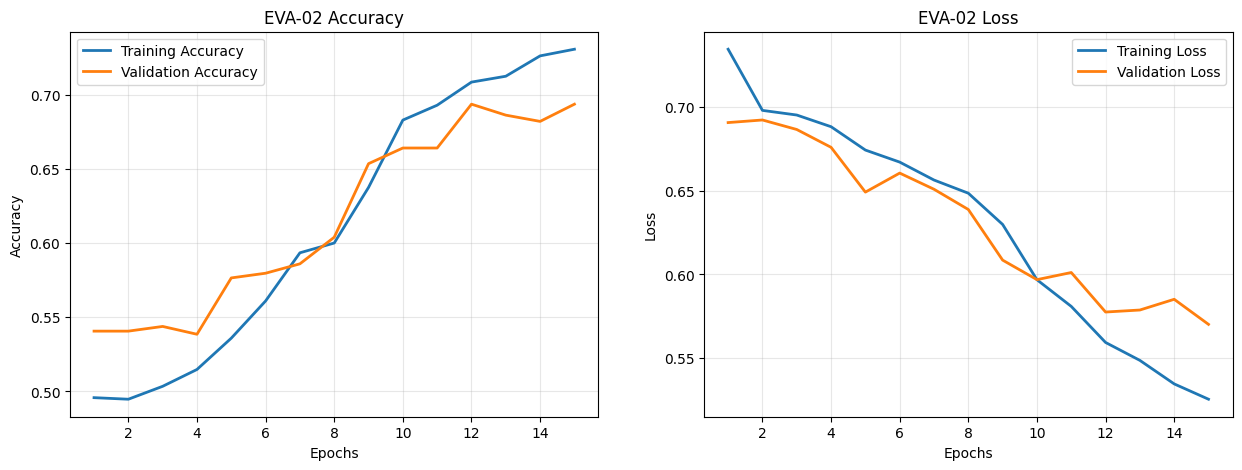


🧮 กำลังคำนวณคะแนนสุทธิ...

🏆 [EVA-02] Train Accuracy: 73.59%
🎯 [EVA-02] Valid Accuracy: 69.38%

🚀 กำลังทำข้อสอบจริง (Test Set) และบันทึกผล...
36/36 [==============================] - 14s 310ms/step

🎉 บันทึกไฟล์ 'submission_eva02_final.csv' เรียบร้อย! นำไปส่ง Kaggle ได้เลยครับ!


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ==========================================
# 📈 1. พล็อตกราฟประวัติการเรียนรู้ (Learning Curves)
# ==========================================
def plot_final_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 5))
    
    # กราฟ Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
    plt.title('EVA-02 Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # กราฟ Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ff7f0e', lw=2)
    plt.title('EVA-02 Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_final_history(history)

# ==========================================
# 📊 2. ประเมินผลคะแนนอย่างเป็นทางการ
# ==========================================
print("\n🧮 กำลังคำนวณคะแนนสุทธิ...")
train_score = model.evaluate(train_gen, verbose=0)
valid_score = model.evaluate(valid_gen, verbose=0)

print(f"\n🏆 [EVA-02] Train Accuracy: {train_score[1]*100:.2f}%")
print(f"🎯 [EVA-02] Valid Accuracy: {valid_score[1]*100:.2f}%")

# ==========================================
# 📝 3. สร้างไฟล์ส่ง Kaggle (The Path to 1.0)
# ==========================================
print("\n🚀 กำลังทำข้อสอบจริง (Test Set) และบันทึกผล...")
test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)

submission = pd.DataFrame({'ID': test_df['ID'], 'Target': y_pred})
# แปลงกลับเป็นชื่อคลาส
submission['Target'] = submission['Target'].map({0: 'chihuahua', 1: 'muffin'})

# กรอง ID ซ้ำซ้อนเผื่อไว้
submission = submission.drop_duplicates(subset=['ID'], keep='first')
submission.to_csv('submission_eva02_final.csv', index=False)

print("\n🎉 บันทึกไฟล์ 'submission_eva02_final.csv' เรียบร้อย! นำไปส่ง Kaggle ได้เลยครับ!")